# 03 XGBoost and Hybrid Model

This notebook studies two related models:

1. a tuned `XGBoost` predictor,
2. a hybrid `XGBoost + residual TCN` model.

The hybrid uses XGBoost as the main forecast and a small sequence model only on the remaining residual error.

## Modeling idea

The XGBoost stage treats each `(Ticker, Date)` row as a nonlinear tabular forecasting problem. The hybrid stage keeps that base prediction fixed and trains a small temporal model on the remaining log-volatility residual.

In [1]:
from pathlib import Path
import copy
import json
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
MODEL_ARTIFACT_DIR = ARTIFACT_DIR / 'models'
METADATA_DIR = ARTIFACT_DIR / 'metadata'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Data, feature sets, and fixed configurations

The XGBoost stage uses the rich tabular feature family. The residual sequence stage uses the `fast_current` temporal feature family. All results are evaluated with the same train/validation/test year split.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

stock_feature_columns = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'hist_vol_5d', 'hist_vol_10d', 'hist_vol_21d', 'hist_vol_63d',
    'realized_vol_5d', 'realized_vol_10d', 'realized_vol_21d', 'realized_vol_63d',
    'volume_zscore_5d', 'volume_zscore_10d', 'volume_zscore_21d', 'volume_zscore_63d',
    'return_mean_5d', 'return_mean_21d',
    'abs_return_mean_5d', 'abs_return_mean_21d',
    'parkinson_vol_5d', 'parkinson_vol_21d',
]
dynamic_proxy_columns = [
    col for col in model_df.columns
    if (col.startswith('mkt_') or col.startswith('macro_')) and not col.endswith('_proxy_level')
]
xgb_numeric_features = stock_feature_columns + dynamic_proxy_columns

fast_current_features = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
categorical_features = ['Ticker']
train_end_year = 2023
validation_year = 2024
test_year = 2025

best_xgb_params = {
    'n_estimators': 200,
    'max_depth': 3,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_lambda': 5,
}

residual_tcn_config = {
    'lookback': 90,
    'channels': [48, 48, 48, 48],
    'kernel_size': 3,
    'dropout': 0.25,
    'ticker_embedding_dim': 8,
    'batch_size': 512,
    'epochs': 20,
    'patience': 5,
    'learning_rate': 3e-4,
    'weight_decay': 1e-3,
}

pd.DataFrame({
    'xgb_feature_count': [len(xgb_numeric_features)],
    'residual_sequence_feature_count': [len(fast_current_features)],
    'lookback': [residual_tcn_config['lookback']],
})

,xgb_feature_count,residual_sequence_feature_count,lookback
0,85,31,90


In [3]:
def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    low_cut = np.quantile(y_true, 0.20)
    low_mask = y_true <= low_cut
    low_errors = y_pred[low_mask] - y_true[low_mask]
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
        'low_vol_mae': float(np.mean(np.abs(low_errors))),
        'low_vol_bias': float(np.mean(low_errors)),
    }

def build_xgb_pipeline(params):
    preprocess = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', xgb_numeric_features),
            ('ticker', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features),
        ]
    )
    model = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=4,
        verbosity=0,
        **params,
    )
    return Pipeline([('preprocess', preprocess), ('model', model)])

def predict_log_vol(pipeline, df):
    return np.asarray(pipeline.predict(df[categorical_features + xgb_numeric_features]), dtype=float)


## Residual TCN helper code

The residual TCN is intentionally compact. It is designed to capture local temporal structure that the tabular model may not fully absorb.

In [4]:
class ResidualSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        return {
            'x': torch.tensor(panel['features'][start_idx:end_idx + 1], dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'base_log_pred': torch.tensor(panel['base_log_pred'][end_idx], dtype=torch.float32),
            'residual_target': torch.tensor(panel['residual_target'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.left_padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation)

    def forward(self, x):
        x = nn.functional.pad(x, (self.left_padding, 0))
        return self.conv(x)

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation)
        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

    def forward(self, x):
        residual = x if self.downsample is None else self.downsample(x)
        out = self.dropout(self.activation(self.conv1(x)))
        out = self.dropout(self.activation(self.conv2(out)))
        return self.activation(out + residual)

class ResidualTCN(nn.Module):
    def __init__(self, input_dim, num_tickers, channels, kernel_size, dropout, ticker_embedding_dim):
        super().__init__()
        blocks = []
        in_channels = input_dim
        for i, out_channels in enumerate(channels):
            blocks.append(TemporalBlock(in_channels, out_channels, kernel_size, 2 ** i, dropout))
            in_channels = out_channels
        self.tcn = nn.Sequential(*blocks)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(channels[-1] + ticker_embedding_dim + 1, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx, base_log_pred):
        x = x.transpose(1, 2)
        encoded = self.tcn(x)
        seq_repr = encoded[:, :, -1]
        ticker_repr = self.ticker_embedding(ticker_idx)
        head_input = torch.cat([seq_repr, ticker_repr, base_log_pred.unsqueeze(1)], dim=1)
        return self.head(head_input).squeeze(-1)

def prepare_residual_data(df, feature_list, lookback, batch_size, train_years, val_years, test_years):
    panel_df = df[target_columns + ['base_log_pred', 'residual_target'] + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = panel_df['Date'].dt.year.isin(train_years)
    feature_mean = panel_df.loc[train_mask, feature_list].mean()
    feature_std = panel_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    panel_df[feature_list] = (panel_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(panel_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped = {}
    for ticker, group in panel_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'base_log_pred': group['base_log_pred'].to_numpy(dtype=np.float32),
            'residual_target': group['residual_target'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    return {
        'num_tickers': len(ticker_levels),
        'train_loader': DataLoader(ResidualSequenceDataset(grouped, ticker_to_idx, lookback, train_years), batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(ResidualSequenceDataset(grouped, ticker_to_idx, lookback, val_years), batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(ResidualSequenceDataset(grouped, ticker_to_idx, lookback, test_years), batch_size=batch_size, shuffle=False, num_workers=0),
        'all_train_loader': DataLoader(ResidualSequenceDataset(grouped, ticker_to_idx, lookback, sorted(set(train_years).union(val_years))), batch_size=batch_size, shuffle=True, num_workers=0),
    }

def run_epoch(model, dataloader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        base_log_pred = batch['base_log_pred'].to(DEVICE)
        residual_target = batch['residual_target'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx, base_log_pred)
            loss = torch.mean((pred - residual_target) ** 2)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_items += x.size(0)
    return total_loss / total_items

@torch.no_grad()
def predict_hybrid(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        base_log_pred = batch['base_log_pred'].to(DEVICE)
        residual_pred = model(x, ticker_idx, base_log_pred).detach().cpu().numpy()
        hybrid_log = batch['base_log_pred'].numpy() + residual_pred
        hybrid_vol = np.exp(np.clip(hybrid_log, -6.0, 6.0))
        base_vol = np.exp(np.clip(batch['base_log_pred'].numpy(), -6.0, 6.0))
        actual_vol = batch['y_vol'].numpy()
        for date, ticker, actual, base_pred, hybrid_pred in zip(batch['date'], batch['ticker'], actual_vol, base_vol, hybrid_vol):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'xgb_prediction': float(base_pred),
                'prediction': float(hybrid_pred),
            })
    return pd.DataFrame(rows)


## Stage 1: fit base XGBoost and tune residual TCN on 2024

The residual TCN uses the 2024 validation set only to choose the stopping point. The XGBoost hyperparameters are fixed from the earlier model-selection stage.

In [5]:
xgb_df = model_df[['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d'] + xgb_numeric_features].copy()
train_df = xgb_df[xgb_df['Date'].dt.year <= train_end_year].copy()
val_df = xgb_df[xgb_df['Date'].dt.year == validation_year].copy()
test_df = xgb_df[xgb_df['Date'].dt.year == test_year].copy()

xgb_tune_model = build_xgb_pipeline(best_xgb_params)
xgb_tune_model.fit(train_df[categorical_features + xgb_numeric_features], train_df['log_fvol_5d'])
train_df['base_log_pred'] = predict_log_vol(xgb_tune_model, train_df)
val_df['base_log_pred'] = predict_log_vol(xgb_tune_model, val_df)

tune_sequence_df = model_df[target_columns + fast_current_features].copy().merge(
    pd.concat([train_df[['Date', 'Ticker', 'base_log_pred']], val_df[['Date', 'Ticker', 'base_log_pred']]], axis=0),
    on=['Date', 'Ticker'],
    how='inner',
).sort_values(['Ticker', 'Date']).reset_index(drop=True)
tune_sequence_df['residual_target'] = tune_sequence_df['log_fvol_5d'] - tune_sequence_df['base_log_pred']

tune_panel = prepare_residual_data(
    tune_sequence_df,
    feature_list=fast_current_features,
    lookback=residual_tcn_config['lookback'],
    batch_size=residual_tcn_config['batch_size'],
    train_years=range(2016, train_end_year + 1),
    val_years=[validation_year],
    test_years=[],
)

residual_model = ResidualTCN(
    input_dim=len(fast_current_features),
    num_tickers=tune_panel['num_tickers'],
    channels=residual_tcn_config['channels'],
    kernel_size=residual_tcn_config['kernel_size'],
    dropout=residual_tcn_config['dropout'],
    ticker_embedding_dim=residual_tcn_config['ticker_embedding_dim'],
).to(DEVICE)
optimizer = torch.optim.AdamW(residual_model.parameters(), lr=residual_tcn_config['learning_rate'], weight_decay=residual_tcn_config['weight_decay'])

best_state = None
best_val_loss = float('inf')
best_epoch = None
epochs_without_improvement = 0
history_rows = []

for epoch in range(1, residual_tcn_config['epochs'] + 1):
    train_loss = run_epoch(residual_model, tune_panel['train_loader'], optimizer=optimizer)
    val_loss = run_epoch(residual_model, tune_panel['val_loader'], optimizer=None)
    history_rows.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f"epoch {epoch}/{residual_tcn_config['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(residual_model.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epochs_without_improvement >= residual_tcn_config['patience']:
        print(f"early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
        break

history_df = pd.DataFrame(history_rows)
history_df.tail()

epoch 1/20 | train_loss=0.194823 | val_loss=0.241534


epoch 2/20 | train_loss=0.189653 | val_loss=0.240332


epoch 3/20 | train_loss=0.186012 | val_loss=0.238503


epoch 4/20 | train_loss=0.182643 | val_loss=0.237570


epoch 5/20 | train_loss=0.179868 | val_loss=0.239388


epoch 6/20 | train_loss=0.177539 | val_loss=0.239622


epoch 7/20 | train_loss=0.175132 | val_loss=0.239821


epoch 8/20 | train_loss=0.173760 | val_loss=0.242065


epoch 9/20 | train_loss=0.171766 | val_loss=0.242762
early stopping at epoch 9. Best epoch: 4.


,epoch,train_loss,val_loss
4,5,0.179868,0.239388
5,6,0.177539,0.239622
6,7,0.175132,0.239821
7,8,0.173760,0.242065
8,9,0.171766,0.242762


In [6]:
residual_model.load_state_dict(best_state)
val_hybrid_predictions = predict_hybrid(residual_model, tune_panel['val_loader'])
validation_metric_df = pd.DataFrame([
    {'model': 'xgboost_only', **volatility_metrics(val_hybrid_predictions['fvol_5d'], val_hybrid_predictions['xgb_prediction'])},
    {'model': 'xgboost_plus_residual_tcn', **volatility_metrics(val_hybrid_predictions['fvol_5d'], val_hybrid_predictions['prediction'])},
])
validation_metric_df

,model,rmse,mae,qlike,corr,low_vol_mae,low_vol_bias
0,xgboost_only,0.142855,0.083504,-1.569212,0.437412,0.069738,0.068106
1,xgboost_plus_residual_tcn,0.142268,0.082915,-1.599817,0.446459,0.069187,0.067504


## Final 2025 holdout results

Both stages are refit using all data through 2024, and the final comparison is reported on the 2025 holdout set.

In [7]:
final_train_df = xgb_df[xgb_df['Date'].dt.year < test_year].copy()
final_test_df = xgb_df[xgb_df['Date'].dt.year == test_year].copy()

xgb_final_model = build_xgb_pipeline(best_xgb_params)
xgb_final_model.fit(final_train_df[categorical_features + xgb_numeric_features], final_train_df['log_fvol_5d'])
final_train_df['base_log_pred'] = predict_log_vol(xgb_final_model, final_train_df)
final_test_df['base_log_pred'] = predict_log_vol(xgb_final_model, final_test_df)

final_sequence_df = model_df[target_columns + fast_current_features].copy().merge(
    pd.concat([final_train_df[['Date', 'Ticker', 'base_log_pred']], final_test_df[['Date', 'Ticker', 'base_log_pred']]], axis=0),
    on=['Date', 'Ticker'],
    how='inner',
).sort_values(['Ticker', 'Date']).reset_index(drop=True)
final_sequence_df['residual_target'] = final_sequence_df['log_fvol_5d'] - final_sequence_df['base_log_pred']

final_panel = prepare_residual_data(
    final_sequence_df,
    feature_list=fast_current_features,
    lookback=residual_tcn_config['lookback'],
    batch_size=residual_tcn_config['batch_size'],
    train_years=range(2016, validation_year + 1),
    val_years=[],
    test_years=[test_year],
)

final_residual_model = ResidualTCN(
    input_dim=len(fast_current_features),
    num_tickers=final_panel['num_tickers'],
    channels=residual_tcn_config['channels'],
    kernel_size=residual_tcn_config['kernel_size'],
    dropout=residual_tcn_config['dropout'],
    ticker_embedding_dim=residual_tcn_config['ticker_embedding_dim'],
).to(DEVICE)
optimizer = torch.optim.AdamW(final_residual_model.parameters(), lr=residual_tcn_config['learning_rate'], weight_decay=residual_tcn_config['weight_decay'])

for epoch in range(1, best_epoch + 1):
    train_loss = run_epoch(final_residual_model, final_panel['all_train_loader'], optimizer=optimizer)
    print(f"final refit epoch {epoch}/{best_epoch} | train_loss={train_loss:.6f}")

hybrid_predictions_df = predict_hybrid(final_residual_model, final_panel['test_loader'])
test_metric_df = pd.DataFrame([
    {'model': 'xgboost_only', **volatility_metrics(hybrid_predictions_df['fvol_5d'], hybrid_predictions_df['xgb_prediction'])},
    {'model': 'xgboost_plus_residual_tcn', **volatility_metrics(hybrid_predictions_df['fvol_5d'], hybrid_predictions_df['prediction'])},
])
test_metric_df

final refit epoch 1/4 | train_loss=0.199127


final refit epoch 2/4 | train_loss=0.193931


final refit epoch 3/4 | train_loss=0.189938


final refit epoch 4/4 | train_loss=0.187140


,model,rmse,mae,qlike,corr,low_vol_mae,low_vol_bias
0,xgboost_only,0.159819,0.095069,-1.343346,0.525388,0.072897,0.071170
1,xgboost_plus_residual_tcn,0.158365,0.093928,-1.356904,0.537568,0.071923,0.069505


## Save trained artifacts

The project saves the trained base and hybrid models so they can be reused later without rerunning the full notebook.

In [8]:
xgb_model_path = MODEL_ARTIFACT_DIR / 'xgboost_base_pipeline.joblib'
hybrid_tcn_path = MODEL_ARTIFACT_DIR / 'xgboost_residual_tcn_state_dict.pt'
metadata_path = METADATA_DIR / '03_xgboost_and_hybrid_metadata.json'

joblib.dump(xgb_final_model, xgb_model_path)
torch.save(
    {
        'state_dict': final_residual_model.state_dict(),
        'config': residual_tcn_config,
        'feature_list': fast_current_features,
        'best_epoch': int(best_epoch),
        'train_end_year': int(validation_year),
        'test_year': int(test_year),
        'selected_tickers': selected_tickers,
    },
    hybrid_tcn_path,
)

metadata_payload = {
    'xgb_model_path': str(xgb_model_path),
    'hybrid_tcn_path': str(hybrid_tcn_path),
    'xgb_params': best_xgb_params,
    'residual_tcn_config': residual_tcn_config,
    'residual_feature_list': fast_current_features,
    'validation_metrics': validation_metric_df.to_dict(orient='records'),
    'test_metrics': test_metric_df.to_dict(orient='records'),
}
metadata_path.write_text(json.dumps(metadata_payload, indent=2))

pd.DataFrame([
    {'artifact': 'xgb_pipeline', 'path': str(xgb_model_path)},
    {'artifact': 'hybrid_residual_tcn', 'path': str(hybrid_tcn_path)},
    {'artifact': 'metadata', 'path': str(metadata_path)},
])

,artifact,path
0,xgb_pipeline,/Users/chonggu/Documents/Mine/Erdos 2026 Sprin...
1,hybrid_residual_tcn,/Users/chonggu/Documents/Mine/Erdos 2026 Sprin...
2,metadata,/Users/chonggu/Documents/Mine/Erdos 2026 Sprin...


In [9]:
hybrid_predictions_df.head()

,Date,Ticker,fvol_5d,xgb_prediction,prediction
0,2025-01-02,AAPL,0.198237,0.185743,0.178309
1,2025-01-03,AAPL,0.211053,0.163641,0.152849
2,2025-01-06,AAPL,0.208389,0.170669,0.166335
3,2025-01-07,AAPL,0.236536,0.176225,0.169047
4,2025-01-08,AAPL,0.376107,0.166237,0.166894


## Five-stock visualization

The plot compares the actual volatility curve, the XGBoost forecast, and the hybrid forecast for representative stocks.

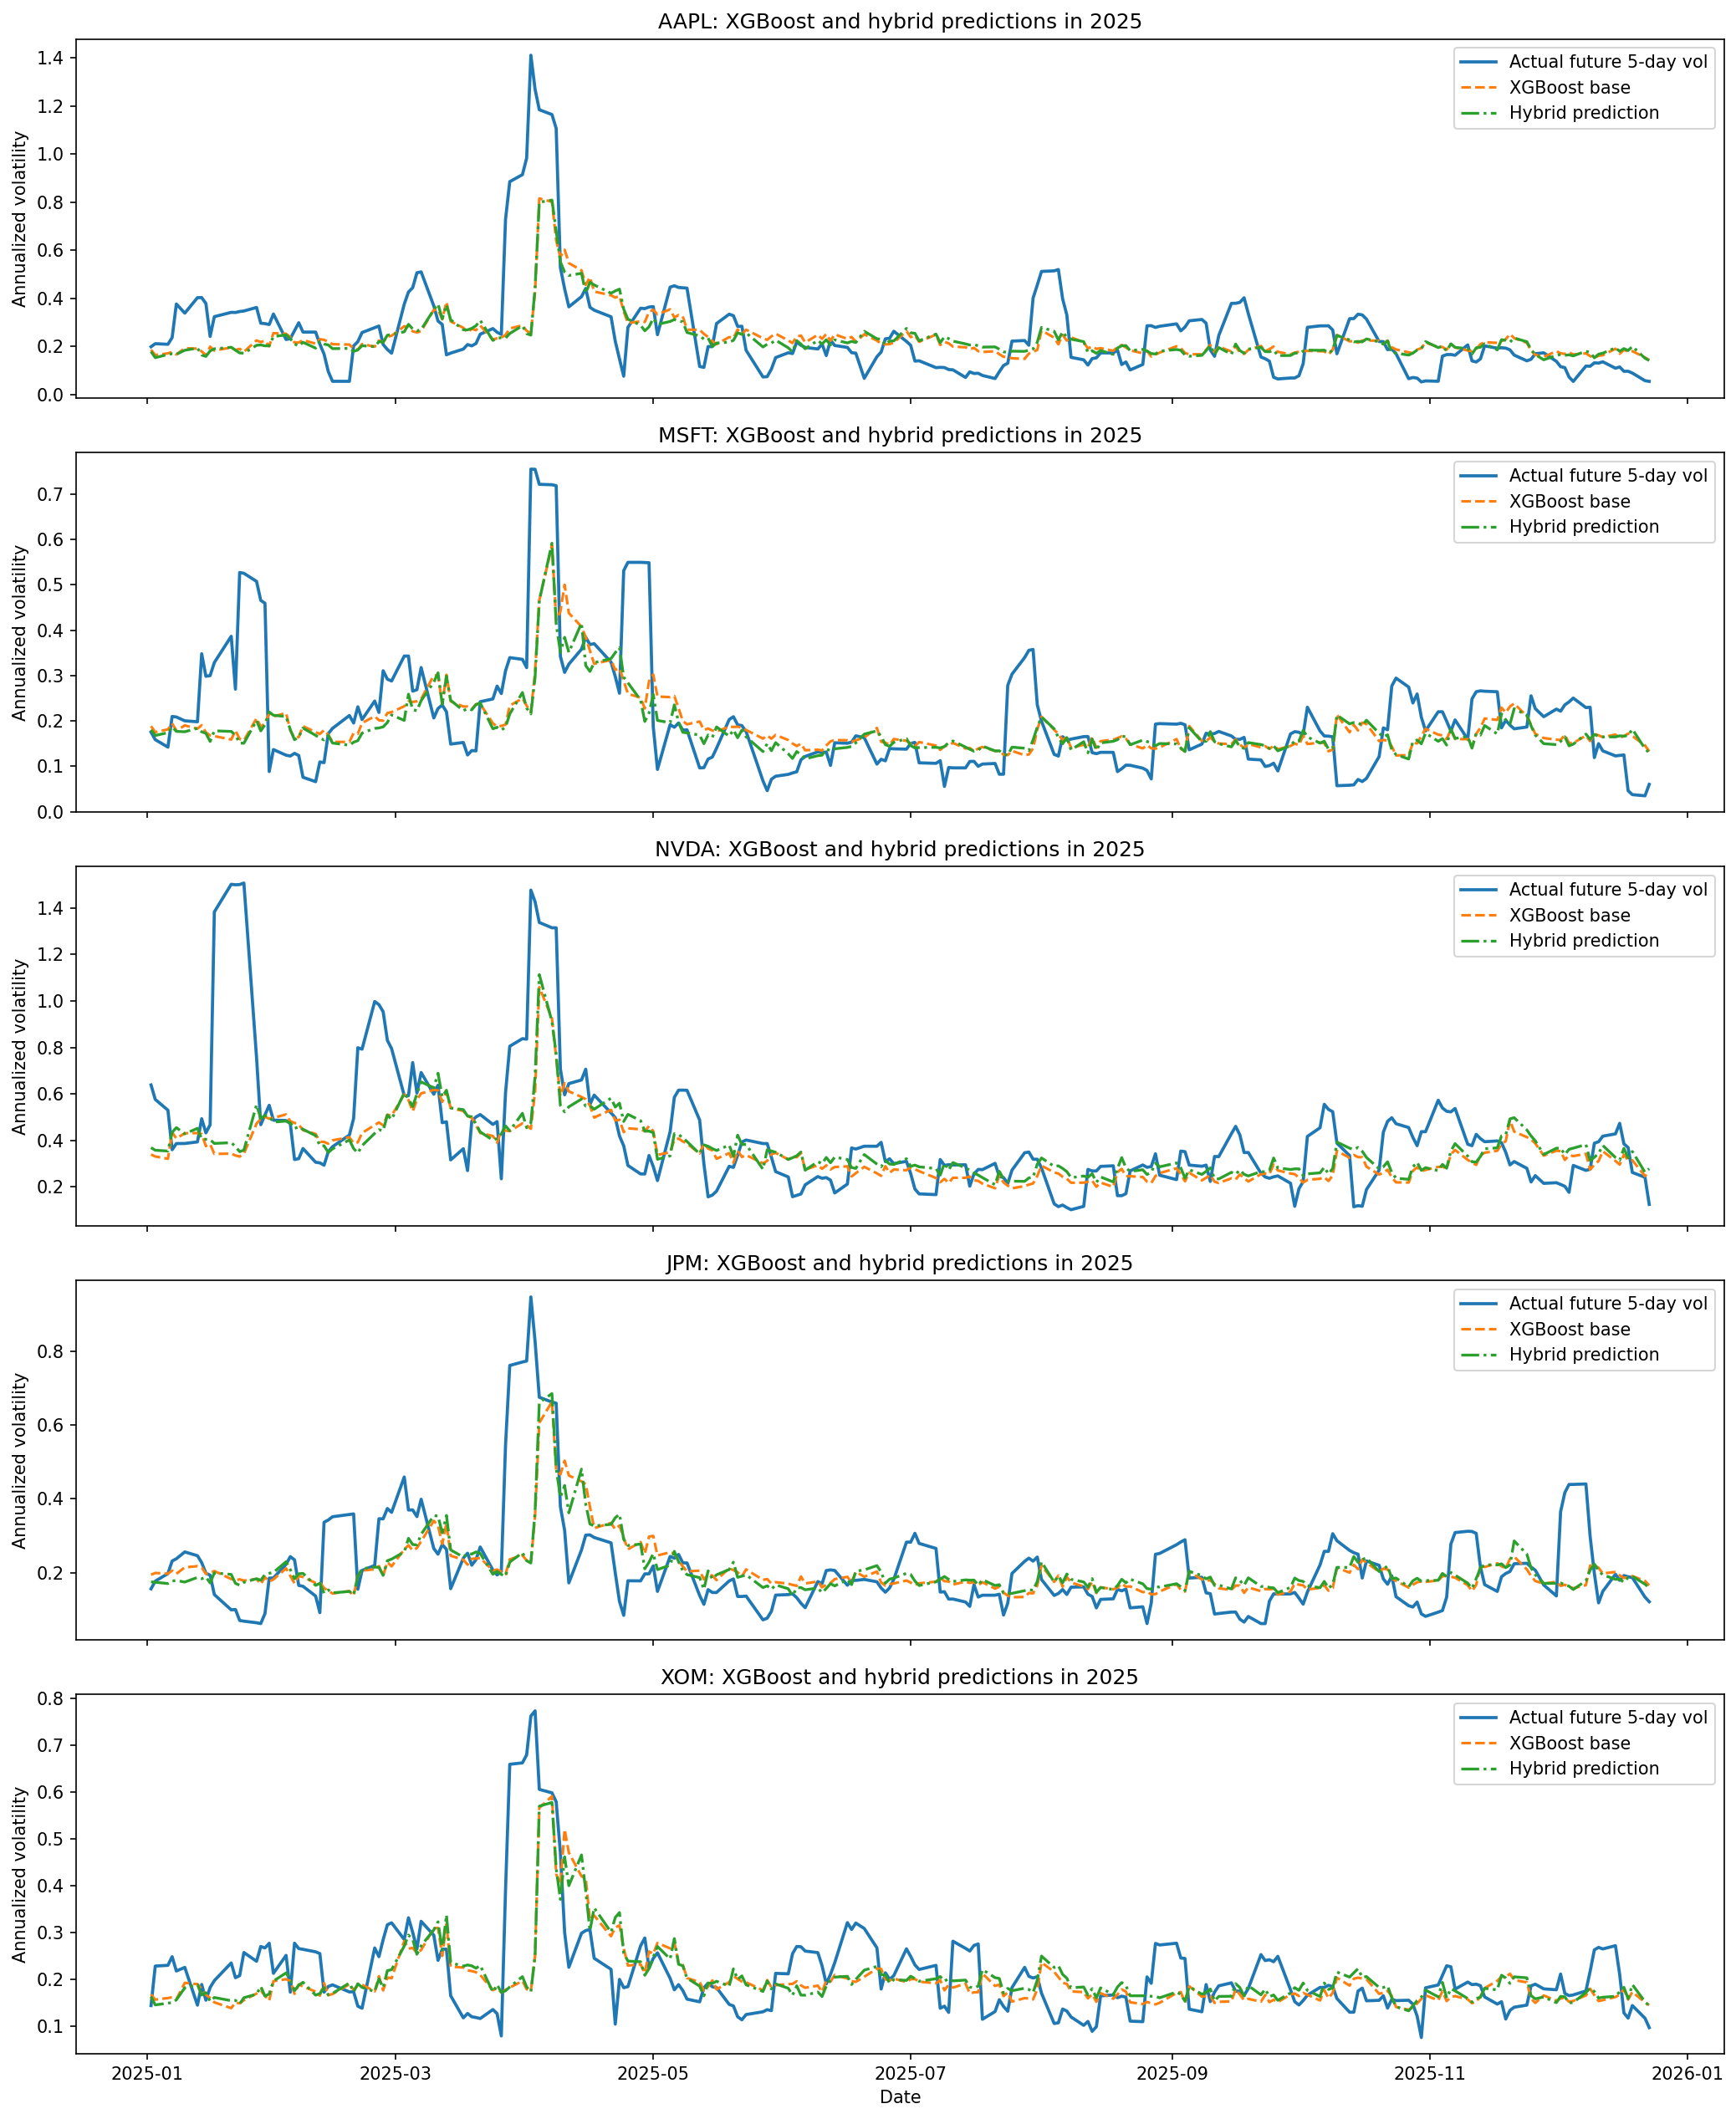

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/03_xgboost_and_hybrid_5stocks.png')

In [10]:
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 17), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = hybrid_predictions_df[hybrid_predictions_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df['xgb_prediction'], label='XGBoost base', linestyle='--', linewidth=1.5)
    ax.plot(stock_plot_df['Date'], stock_plot_df['prediction'], label='Hybrid prediction', linestyle='-.', linewidth=1.6)
    ax.set_title(f'{ticker}: XGBoost and hybrid predictions in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

plot_path = FIGURE_DIR / '03_xgboost_and_hybrid_5stocks.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(plot_path)))

plot_path